In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import MDS
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas.plotting import parallel_coordinates

warnings.filterwarnings('ignore')


In [2]:
# load the modified dataset
df = pd.read_csv('flood_risk_dataset_modified.csv') 
df.head()

,county,nearest_town,town_size,landcover_types,elevation_m,dist_to_town_m,dist_to_water_m,topographic_hazard,landcover_risk,water_proximity_risk,vulnerability_score,flood_risk_score,risk_category
0,Migori,Mohoni,Town,waterbodies,1134.0,14191.648756,9.891734e+06,0.0,9.0,0,0.0,2.2,High Risk
1,Migori,Mohoni,Town,waterbodies,1134.0,16419.789667,9.898062e+06,0.0,9.0,0,0.0,2.2,High Risk
2,Migori,Nyatembe,Town,waterbodies,1134.0,18365.752928,9.904390e+06,0.0,9.0,0,0.0,2.2,High Risk
3,Migori,Nyandhiwa,Town,waterbodies,1134.0,13839.292053,9.910718e+06,0.0,9.0,0,0.0,2.2,High Risk
4,Homa Bay,Nyandhiwa,Town,waterbodies,1134.0,10562.446388,9.917045e+06,0.0,9.0,0,0.0,2.2,High Risk


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14497 entries, 0 to 14496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   county                14497 non-null  object 
 1   nearest_town          14497 non-null  object 
 2   town_size             14497 non-null  object 
 3   landcover_types       14497 non-null  object 
 4   elevation_m           14497 non-null  float64
 5   dist_to_town_m        14497 non-null  float64
 6   dist_to_water_m       14497 non-null  float64
 7   topographic_hazard    14497 non-null  float64
 8   landcover_risk        14497 non-null  float64
 9   water_proximity_risk  14497 non-null  int64  
 10  vulnerability_score   14497 non-null  float64
 11  flood_risk_score      14497 non-null  float64
 12  risk_category         14497 non-null  object 
dtypes: float64(7), int64(1), object(5)
memory usage: 1.4+ MB


## Univariate Analysis


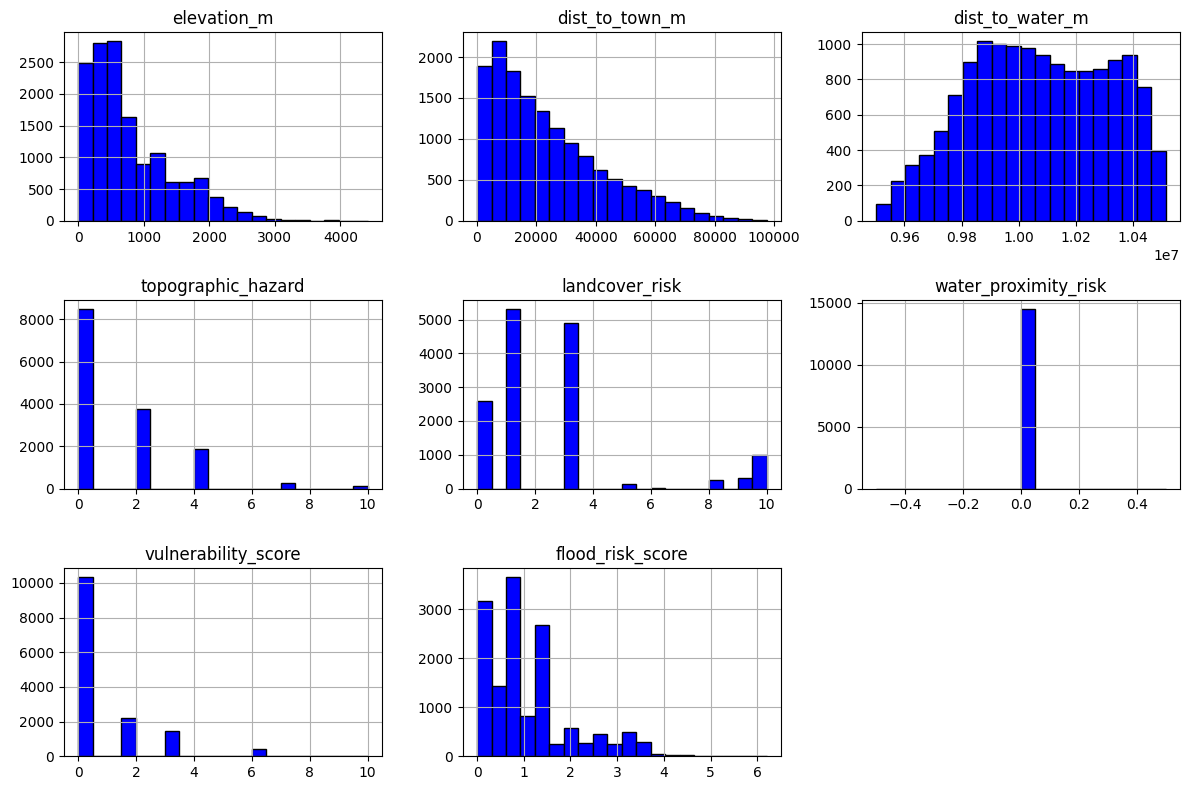

In [4]:
# Visualize the distribution of numerical features
df.hist(figsize=(12, 8), bins=20, color='blue', edgecolor='black')
plt.tight_layout()
plt.xlabel(df.columns.str.replace('_', ' ').str.title(), fontsize=12)
plt.ylabel('Frequency', fontsize=12)  
plt.title('Distribution of Numerical Features', fontsize=14)      
plt.show()

#### **Observations for the histogram**

1. Physical & Geographic Distribution
Elevation & Proximity: Most data points represent low-lying areas (peaking under 1,000m) that are relatively close to towns (peaking between 0 and 20,000m).
Water Proximity: The dist_to_water_m graph shows a high concentration of data around a very specific, large-scale value (or 10,000 km), which may indicate a data normalization issue or that most locations in this dataset are extremely far from a primary water source.

2. Risk & Hazard Categorization
Binary/Categorical Risks: Many "risk" variables (topographic_hazard, landcover_risk, vulnerability_score) are not continuous. Instead, they show high frequencies at specific integer intervals (e.g., 0, 2, 4, 10).
Low Baseline Risk: In almost all hazard categories, the highest frequency occurs at the 0 value, suggesting that a large majority of the areas sampled are considered "low risk" for those specific metrics.
Water Proximity Risk: This histogram is essentially a single vertical bar at 0. This implies that for this specific dataset, water proximity does not currently contribute to a high risk score for nearly any of the recorded locations.

3. The Final Flood Risk Score
Skewed Distribution: The flood_risk_score is heavily right-skewed. Most scores fall between 0 and 2.
Primary Drivers: Given that topographic_hazard and vulnerability_score share similar "stepped" distributions with the final flood risk, these likely act as the primary inputs for calculating the final risk level.
Outliers: There is a very small "long tail" of areas with a score between 4 and 6. These represent high-priority locations for mitigation efforts, even though they are statistically rare in this dataset.
Summary Insight: This dataset describes a region where the overall environmental hazard is low. Risk is concentrated in a few specific high-score "hotspots" rather than being a widespread issue.

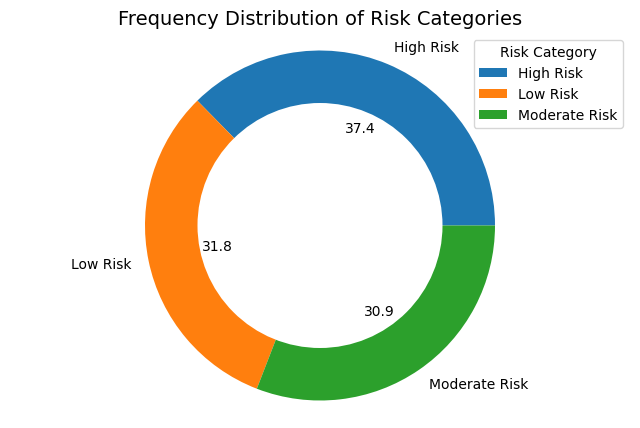

In [5]:
# frequecy distribution of risk category
risk_category = df['risk_category'].value_counts()
plt.figure(figsize=(8, 5))
plt.pie(risk_category,labels=risk_category.index, autopct = "%1.1f")

# blank circle in the middle of the pie chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)


plt.title('Frequency Distribution of Risk Categories', fontsize=14)
plt.axis('equal')
plt.legend(title='Risk Category', loc='upper right')
plt.show()




### **Key Observations**

- High Risk is the largest category: At 37.4%, the "High Risk" group represents the biggest portion of the data.

- Balanced Distribution: All three categories are relatively close in size, with only a 6.5% difference between the largest (High Risk) and smallest (Moderate Risk) segments.
Moderate Risk is the smallest: This category accounts for 30.9% of the total frequency.

- Low Risk sits in the middle: Representing 31.8%, it is nearly equal to the Moderate Risk category.

**Insights**

- Significant Risk Exposure: Over one-third of the subjects or areas analyzed fall into the "High Risk" category. If this chart represents safety or financial data, it suggests a situation that requires immediate attention or mitigation.
- Combined Risk Concerns: When you combine "High" and "Moderate" risk, they account for 68.3% of the total. This indicates that more than two-thirds of the dataset involves some level of elevated risk.
- Lack of a Clear Majority: Because the percentages are so close (37.4%, 31.8%, and 30.9%), no single risk category dominates the dataset. This suggests a diverse set of conditions across the population being measured

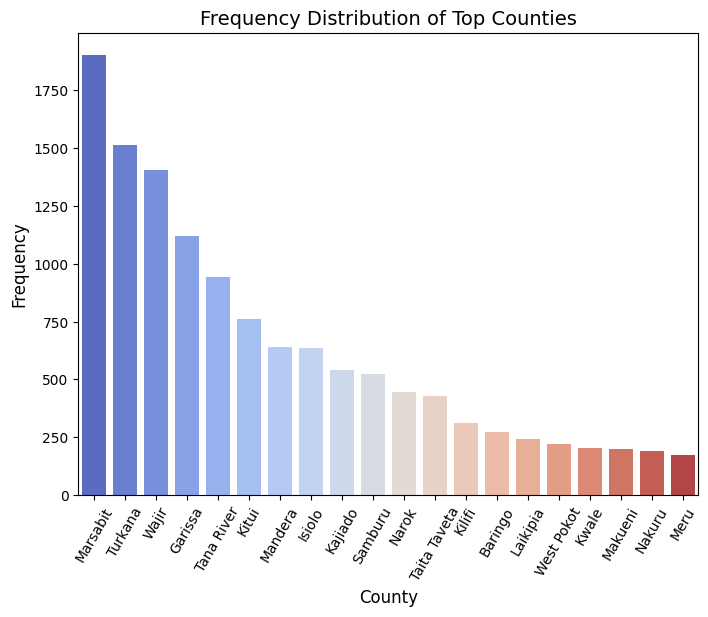

In [6]:
#Distribution of Top Counties
county_counts = df['county'].value_counts().head(20)  # Get the top 20 counties
plt.figure(figsize=(8, 6))
sns.barplot(x=county_counts.index, y=county_counts.values, palette='coolwarm')
plt.xlabel('County', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Frequency Distribution of Top Counties', fontsize=14)
plt.xticks(rotation=60)
plt.show()

### **Key Observations**

- Highest Frequency: Marsabit has the highest frequency, approaching 1,900.
- Top Three Dominance: Marsabit, Turkana, and Wajir significantly outperform the other counties, all exceeding a frequency of 1,250.
- Steep Initial Decline: There is a sharp drop in frequency between the top five counties (Marsabit to Tana River) compared to the rest of the list.
- Lowest Frequency: Meru has the lowest frequency among the "Top Counties" displayed, appearing below 250.
- Geographic Concentration: The top-ranking counties (Marsabit, Turkana, Wajir, Garissa) are primarily located in the Arid and Semi-Arid Lands (ASAL) regions of Northern and Eastern Kenya.

**Insights**

1. Regional Imbalance: The data is heavily skewed toward a small number of counties. The top three counties alone likely account for a large percentage of the total data points in this set.
2. High-Priority "Hotspot" Counties
- Northern Dominance: Marsabit, Turkana, and Wajir show the highest frequencies. In a flood risk context, this suggests these counties have the most vulnerable points or historical incidents.
- Arid Land Risk: Interestingly, the top counties are primarily ASAL (Arid and Semi-Arid Lands) regions. While these areas are dry, they are highly susceptible to flash flooding due to poor soil absorption and lack of drainage infrastructure.
3. Vulnerability vs. Frequency
- The Steep Decline: The sharp drop in frequency after Tana River and Kitui indicates that flood-related data points are not evenly spread across Kenya. Risk is highly localized.
- Data Concentration: The top 5 counties (Marsabit to Tana River) likely represent the vast majority of the "High Risk" zones identified in your previous donut chart.
4. Strategic Insights for Mitigation
- Resource Allocation: Disaster management funds, early warning systems, and drainage infrastructure should be prioritized for the top three counties, as they represent the highest "frequency" of risk or recorded incidents.
- Geographic Correlation: Many of these top counties (Garissa, Tana River) sit along major river basins (like the Tana River). The high frequency reflects the recurring seasonal flooding of these specific water bodies.
- The "Long Tail": Counties like Meru and Nakuru have much lower frequencies. This doesn't mean they don't flood, but rather that flood events there are likely more isolated or less severe compared to the systemic risks in the northern counties

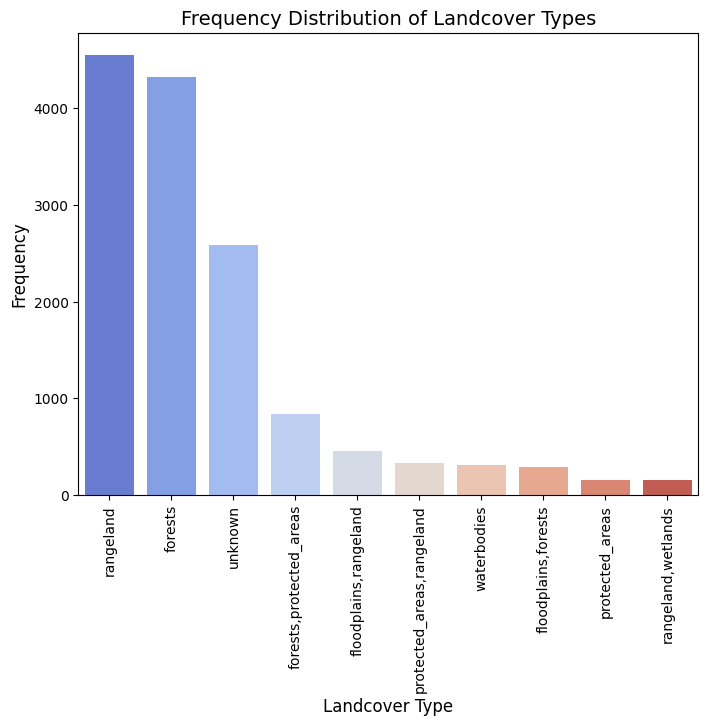

In [7]:
# Distribution of landcover types
landcover_counts = df['landcover_types'].value_counts().head(10)  # Get the top 10 landcover types
plt.figure(figsize=(8, 6))
sns.barplot(x=landcover_counts.index, y=landcover_counts.values, palette='coolwarm')
plt.xlabel('Landcover Type', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Frequency Distribution of Landcover Types', fontsize=14)
plt.xticks(rotation=90)
plt.show()


### **Observations**

- Dominant Landcovers: Rangeland (approx. 4,500) and Forests (approx. 4,300) make up the overwhelming majority of the study area.
- High "Unknown" Count: A significant portion of the data (~2,600) is categorized as Unknown, which could represent a data gap or unclassified urban/barren land.
- Low Occurrence of High-Risk Zones: Directly flood-prone types like Floodplains and Wetlands appear with much lower frequency at the tail end of the chart.

**Flood Risk Insights**

1. The Rangeland Factor: Since rangeland is the most frequent type, its soil health is your biggest variable. Overgrazed or compacted rangeland in counties like Marsabit or Turkana leads to high runoff and flash floods, even far from rivers.
2. Forest Buffer: The high frequency of forests is a positive indicator for flood mitigation. These areas likely act as natural sponges, reducing peak flow and protecting downstream regions.
3. Floodplain Dynamics: The low frequency of "Floodplains, rangeland" and "Floodplains, forests" suggests that while these are high-hazard zones, they are geographically limited. Risk in these areas is likely high-severity but low-frequency relative to the whole dataset.
4. Potential Data Blind Spot: The "Unknown" category is large enough to skew your model. If these areas are actually urban centers or impervious surfaces, the flood risk in those specific locations would be significantly higher than the natural landcovers.

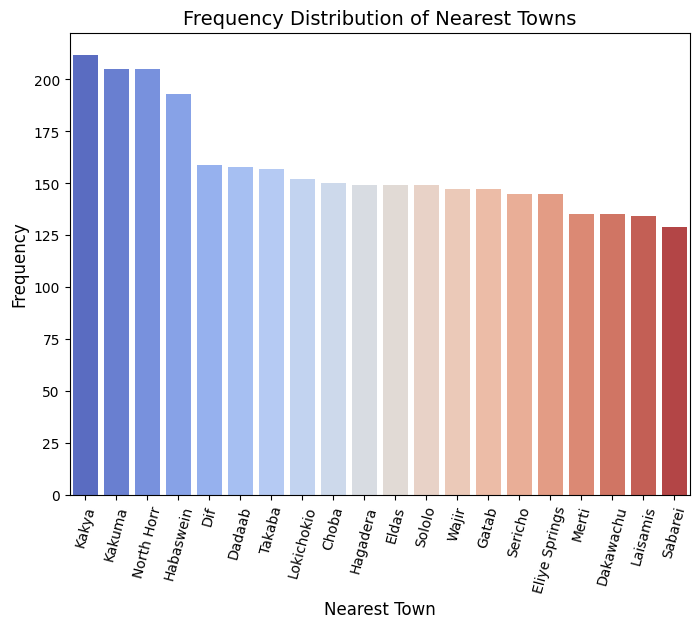

In [8]:
# Distribution of Top Nearest Towns
nearest_towns_counts = df['nearest_town'].value_counts().head(20)  # Get the top 20 nearest towns
plt.figure(figsize=(8, 6))
sns.barplot(x=nearest_towns_counts.index, y=nearest_towns_counts.values, palette='coolwarm')
plt.xlabel('Nearest Town', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Frequency Distribution of Nearest Towns', fontsize=14)
plt.xticks(rotation=75)
plt.show()

### **Observations**

- Highest Exposure: Kakya, Kakuma, North Horr, and Habaswein are the top four towns. Each is nearest to roughly 200 data points, making them the primary centers of concern for this analysis.
- Relatively Even Spread: Unlike the previous "Top Counties" chart which showed a steep drop, the distribution here is more gradual. Most towns listed are nearest to between 130 and 160 data points.
- Northern Focus: Many of these towns (like Kakuma, North Horr, and Dadaab) are in the same high-frequency counties we saw earlier (Turkana, Marsabit, Garissa).

**Flood Risk Insights**

1. Vulnerability in Arid Settlements: Several of these locations, like Kakuma and Dadaab, host large, densely populated refugee settlements. High frequency in these areas implies a massive human impact if a flood event occurs.
2. Logistical Challenges: Remote towns like Sabarei, Laisamis, and Merti show lower frequencies but are still significantly represented (over 125). Their remoteness makes emergency response much more difficult during flash floods compared to larger hubs like Wajir.
3. Targeted Early Warning: These top 20 towns represent your "front line" for flood alerts. Because the frequencies are so high for the top four, they should be the priority for installing localized water level sensors or community-based disaster management teams.

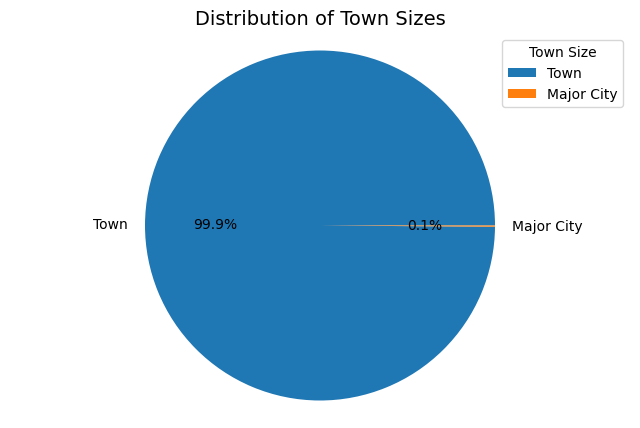

In [9]:
#Distributions of Towns 
town_size_counts = df['town_size'].value_counts()
plt.figure(figsize=(8, 5))
plt.pie(town_size_counts, labels=town_size_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Town Sizes', fontsize=14)
plt.axis('equal')
plt.legend(title='Town Size', loc='upper right')
plt.show()

#### **Key Observations**

- Near-Total Dominance: 99.9% of the data points are associated with "Towns."
Negligible Large-Scale Urbanization: Only 0.1% are classified as "Major Cities."
- Homogeneous Settlement Scale: The dataset is almost entirely comprised of smaller-scale urban or semi-urban environments.

**Flood Risk Insights**
1. Infrastructure Gaps: Small "Towns" often lack the sophisticated drainage systems, paved flood channels, and massive pumping stations found in "Major Cities." This means that even moderate rainfall could lead to significant flooding in 99.9% of your study area.
2. Resilience and Recovery: Major cities typically have more centralized resources for disaster response. Because your data is concentrated in towns, flood impact likely hits localized, potentially under-resourced community infrastructures harder.
3. Data Skew: If your flood model was trained primarily on data from this set, it is optimized for small-town topography. It may not accurately predict flood behavior in a high-density, "Major City" environment with extensive concrete coverage and complex sewer networks.
4. High Human Impact: In regions like Northern Kenya (where many of your earlier towns were located), these "Towns" often serve as critical hubs for large rural populations. A flood in one of these hubs can disrupt supply chains and aid for an entire county.

## Bi-variate Analysis

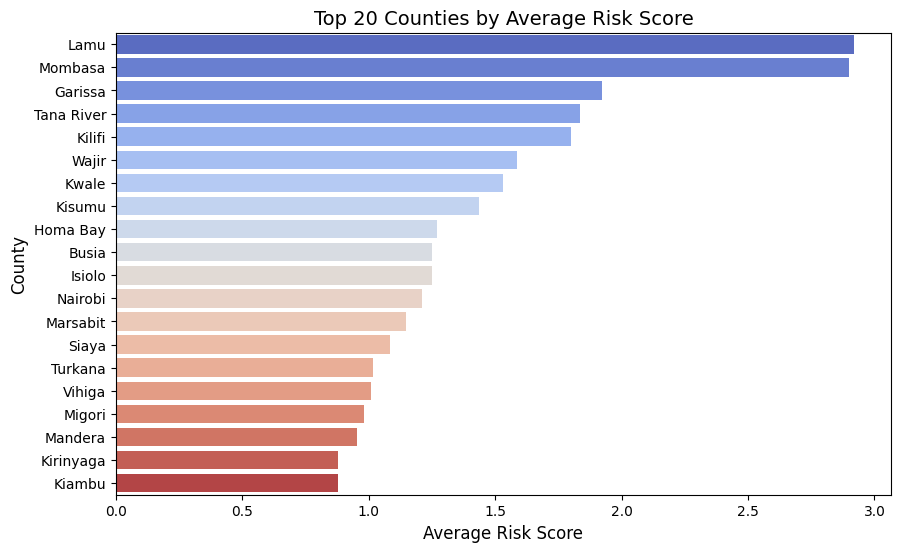

In [10]:
# top counties by risk score
top_counties = df.groupby('county')['flood_risk_score'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_counties.values, y=top_counties.index, palette='coolwarm')
plt.xlabel('Average Risk Score', fontsize=12)
plt.ylabel('County', fontsize=12)
plt.title('Top 20 Counties by Average Risk Score', fontsize=14)
plt.show()

#### **Key Observations**
- Coastal Crisis: The two highest-risk counties are Lamu and Mombasa, both scoring near 3.0. This indicates that coastal flooding (likely driven by sea-level rise and storm surges) is the most severe threat in this model.
- Riverine Risk: Garissa and Tana River follow closely. This aligns with their geographic position along the Tana River basin, which is prone to heavy seasonal flooding.
- The "Top 5" Threshold: There is a notable gap between the top five counties (Lamu to Kilifi) and the rest of the list. These five are the most critical zones for large-scale flood defense infrastructure.
- Urban Risk: Nairobi appears in the middle of the pack (approx. 1.2). While it has high exposure due to population, its average risk score is lower than rural, coastal, or riverine-adjacent counties.

**Flood Risk Insights**
1. Coastal vs. Arid Risk: Interestingly, while Marsabit and Turkana had the highest frequency of data points in your earlier charts, their Average Risk Score is much lower (around 1.0). This suggests that while these areas have many "risk events," the individual events may be less severe than the deep, sustained flooding seen in Lamu or Tana River.
2. Policy Implications:
Lamu and Mombasa require maritime and drainage engineering to combat rising tides.
Garissa and Tana River require dam management and floodplain zoning.
Kiambu and Kirinyaga (at the bottom) have the lowest average risk, likely due to higher elevations and better natural drainage..

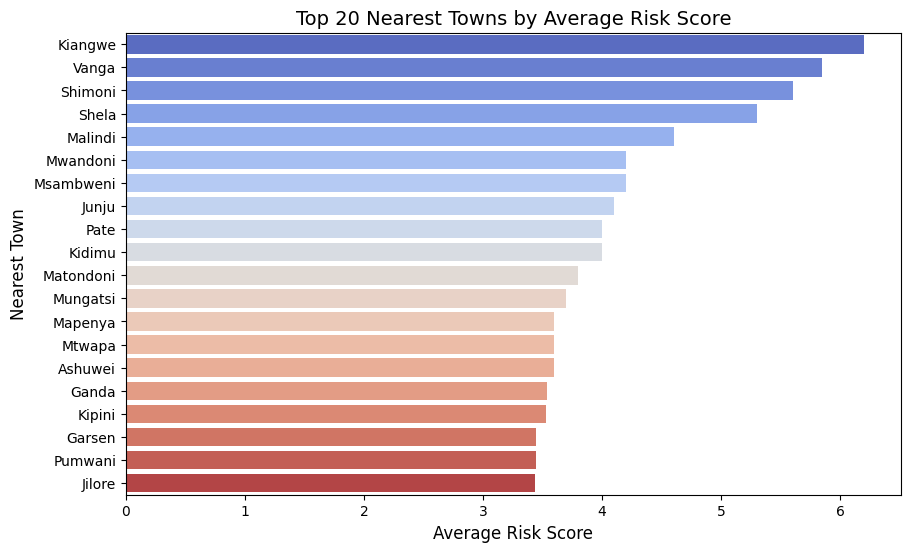

In [11]:
# top nearest towns by risk score
top_towns = df.groupby('nearest_town')['flood_risk_score'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_towns.values, y=top_towns.index, palette='coolwarm', orient='h')
plt.xlabel('Average Risk Score', fontsize=12)
plt.ylabel('Nearest Town', fontsize=12)
plt.title('Top 20 Nearest Towns by Average Risk Score', fontsize=14)

plt.show()

#### **Observations**

- Highest Risk Town: Kiangwe has the highest average risk score, exceeding 6.0. This is significantly higher than the average score for the top counties seen earlier (which peaked around 3.0), indicating that specific towns face extreme localized hazards.
- Top Tier (Scores > 5.0): Kiangwe, Vanga, Shimoni, and Shela are the most critical "high-risk" zones.
- Gradual Decline: Following the top four, the risk scores stabilize between 3.5 and 4.5 for the remaining 16 towns, showing a consistent "high-moderate" risk profile.
- Geographic Clustering: Many of these towns (e.g., Vanga, Shimoni, Malindi, Mtwapa) are coastal towns.

**Flood Risk Analysis Insights**
1. Coastal Vulnerability: The dominance of towns like Kiangwe, Vanga, and Shimoni suggests that coastal flooding—likely a combination of high tides, storm surges, and low elevation—is the most severe threat identified by your model.
2. The Lamu/Kilifi Connection: Towns like Shela, Pate, and Matondoni are located in Lamu County, which you previously identified as the highest-risk county. This chart confirms that the risk in Lamu is concentrated across multiple distinct island and coastal communities.
3. Urban Exposure: While larger hubs like Malindi and Mtwapa have lower average scores than Kiangwe, their higher populations mean the total human impact and economic risk are likely much higher than in the smaller villages.
4. Targeted Infrastructure: For your final project report, these top 20 towns should be the primary candidates for proposed sea walls, mangrove restoration projects, or improved drainage networks

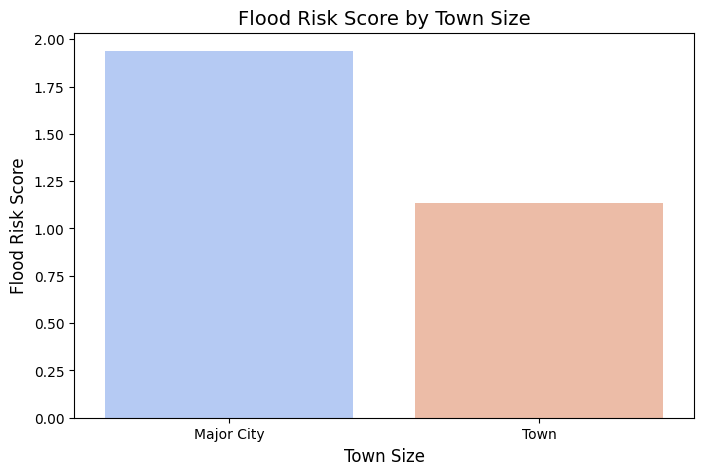

In [12]:
# townsize vs risk score

town_risk_score = df.groupby('town_size')['flood_risk_score'].mean().sort_values(ascending=False)   
plt.figure(figsize=(8, 5))
sns.barplot(x=town_risk_score.index, y=town_risk_score.values, palette='coolwarm', errorbar=None)
plt.xlabel('Town Size', fontsize=12)
plt.ylabel('Flood Risk Score', fontsize=12)
plt.title('Flood Risk Score by Town Size', fontsize=14)
plt.show()

#### **Observations**

- Higher Intensity in Cities: Major Cities have an average flood risk score of nearly 2.0.
Lower Intensity in Towns: Smaller Towns have a significantly lower average score, sitting around 1.15.
- Risk Disparity: On average, a major city in this dataset faces roughly 1.7 times the flood risk of a smaller town.
Flood Risk Project Insights
- The Urban Heat/Runoff Effect: The higher score for Major Cities is likely driven by impervious surfaces (concrete, asphalt). In cities, water cannot soak into the ground, leading to rapid runoff and "flashier" urban flooding compared to more rural towns.

**Concentrated vs. Distributed Risk:**
1. Towns: Represent a distributed risk. There are many of them (high frequency), but the individual risk level is lower.
2. Major Cities: Represent a concentrated risk. There are very few of them (0.1%), but when they are impacted, the severity—and the economic/human cost—is much higher.
3. Drainage vs. Permeability: This visual suggests that the natural drainage in smaller towns (which likely have more open soil and vegetation) is more effective at mitigating flood risk than the artificial drainage systems currently found in Kenya's major cities.
4. Strategic Planning: While your project should address the sheer number of towns at risk, your highest-impact mitigation strategies (like massive underground storm drains) should be targeted at the Major Cities where the risk intensity is peaking

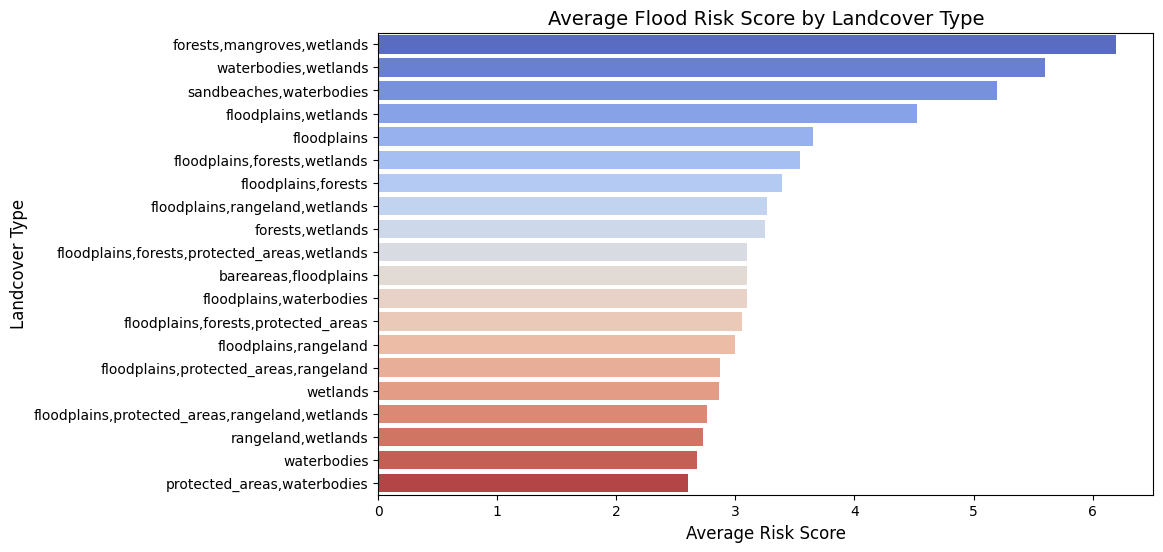

In [13]:
# land cover type vs risk score
landcover_risk_score = df.groupby('landcover_types')['flood_risk_score'].mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=landcover_risk_score.values, y=landcover_risk_score.index, palette='coolwarm', orient='h')
plt.xlabel('Average Risk Score', fontsize=12)
plt.ylabel('Landcover Type', fontsize=12)
plt.title('Average Flood Risk Score by Landcover Type', fontsize=14)
plt.show()


#### **Observations**

- The Highest Risk Duo: The combination of forests, mangroves, and wetlands has the highest average risk score, exceeding 6.0.
The Water/Wetland Factor: Every landcover type in the top four (scoring above 4.5) includes either wetlands or waterbodies.
- Lower Risk "Dry" Combos: Combinations involving rangeland or protected areas tend to fall toward the bottom of the chart, with average risk scores between 2.5 and 3.0.
- Sandbeaches/Waterbodies: These are the third most at-risk category (approx. 5.2), reinforcing your earlier finding that coastal areas (like Lamu and Mombasa) face the most severe threats.

**Flood Risk Analysis Insights**
1. Mangrove & Wetland Sensitivity: While mangroves and wetlands are natural flood buffers, they are located in the lowest-lying areas. Their high risk score in this model likely reflects their exposure to constant flooding and sea-level rise rather than their vulnerability alone.
2. The "Floodplain" Nuance: Interestingly, "floodplains" alone score lower (approx. 3.7) than when they are combined with wetlands (approx. 4.5). This suggests that soil saturation (wetlands) is a bigger driver of risk in your model than just topography (floodplains).
3. Forests as High-Risk Zones? In this specific chart, "forests, mangroves, wetlands" is the most at-risk category. This likely refers to coastal or swamp forests. In a project context, this highlights that these ecosystems are on the "front line" and their degradation would lead to catastrophic flooding for nearby inland towns.
4. Rangeland Stability: Rangeland combinations consistently show lower average risk intensity. This aligns with your earlier county-level data, where high-frequency rangeland counties like Marsabit had lower average risk scores than coastal ones

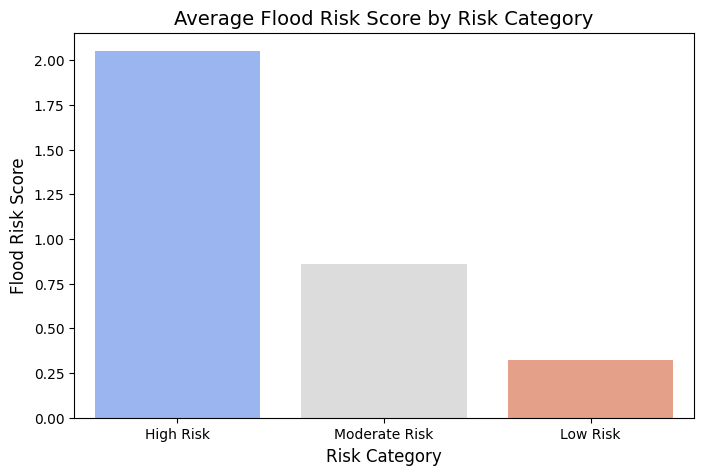

In [14]:
# risk category vs risk score
risk_category_score = df.groupby('risk_category')['flood_risk_score'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=risk_category_score.index, y=risk_category_score.values, palette='coolwarm', errorbar=None)
plt.xlabel('Risk Category', fontsize=12)
plt.ylabel('Flood Risk Score', fontsize=12)
plt.title('Average Flood Risk Score by Risk Category', fontsize=14)
plt.show()

#### **Observations**

- High Risk Benchmark: The average score for the "High Risk" category is just over 2.0.
Moderate Risk Benchmark: This category averages around 0.85.
- Low Risk Benchmark: The baseline for low risk is approximately 0.33.
Exponential-style Gap: The jump from Moderate to High (a difference of ~1.15) is significantly larger than the jump from Low to Moderate (~0.52).

**Flood Risk Analysis Insights**
1. Defining "High Risk": In your model, a score of 2.0 is the critical threshold. Any area reaching this average—like the "Major Cities" identified in your previous chart—is automatically categorized as a top-tier priority.
2. The "Moderate" Buffer: Because the Moderate category is relatively low (under 1.0), it suggests that your "High Risk" category is reserved for areas with significantly more intense environmental or vulnerability factors.
3. Project Calibration: This chart acts as a "legend" for all your previous data. For instance, when you look back at the Towns vs. Cities chart, you can now see that "Major Cities" (averaging ~2.0) are firmly in the High Risk zone, while "Towns" (averaging ~1.15) sit right on the border between Moderate and High Risk.
4. Threshold Sensitivities: If you were to lower the "High Risk" threshold slightly (e.g., to 1.5), a massive number of "Towns" would likely flood into the High Risk category, potentially overwhelming disaster response resources.

### Numeric vs Numeric 

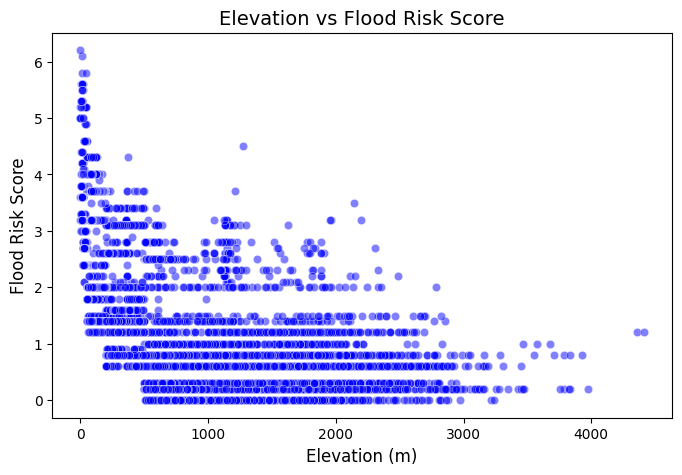

In [15]:
# elevation vs risk score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='elevation_m', y='flood_risk_score', data=df, alpha=0.5, color='blue')
plt.xlabel('Elevation (m)', fontsize=12)
plt.ylabel('Flood Risk Score', fontsize=12)
plt.title('Elevation vs Flood Risk Score', fontsize=14)
plt.show()

### **Key Observations**
- Negative Correlation: There is a clear inverse relationship; as elevation increases, the maximum flood risk score significantly decreases.
- Lowland Concentration: The highest risk scores (above 4.0) are almost exclusively found at elevations below 500 meters. These likely represent coastal zones or deep river basins.
- Risk Tiers: The data appears in distinct horizontal "bands." This suggests that the flood risk score is calculated using discrete categories or weighted factors rather than being a purely continuous calculation.
- High-Altitude Safety: Beyond 3,000 meters, the flood risk score effectively flatlines near zero, with very few outliers.

**Flood Risk Insights**
- Critical Threshold: The 0–500m range is the "danger zone." In this bracket, the risk is not just higher on average, but also more volatile, spanning the full range from 0 to 6.
- Mid-Elevation Outliers: There are several points around 1,200m to 1,500m that maintain high risk scores (approx. 3.0–4.5). This indicates that even in highland areas, factors like local depressions (basins) or proximity to major mountain rivers can override the safety of high elevation.
- Diminishing Returns of Elevation: Once you pass 2,500 meters, additional elevation provides very little "extra" protection, as the risk is already minimized. The most significant drop in risk occurs in the first 1,000 meters of ascent.

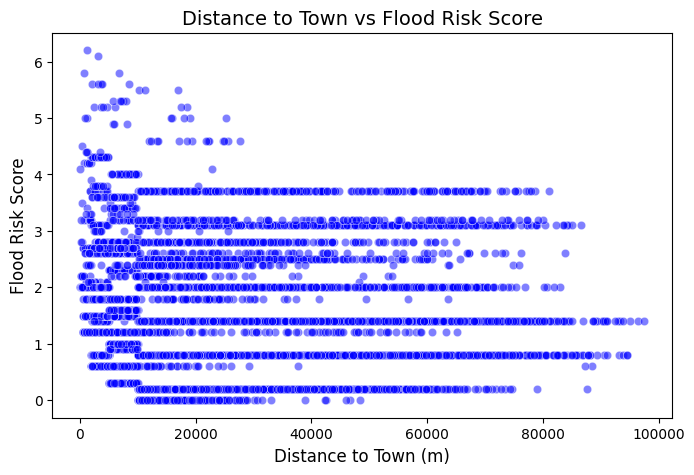

In [16]:
# distance to town vs risk score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='dist_to_town_m', y='flood_risk_score', data=df, alpha=0.5, color='blue')
plt.xlabel('Distance to Town (m)', fontsize=12)
plt.ylabel('Flood Risk Score', fontsize=12)
plt.title('Distance to Town vs Flood Risk Score', fontsize=14)
plt.show()

#### **Key Observations**
- Negative Correlation: There is a clear inverse relationship; as elevation increases, the maximum flood risk score significantly decreases.
- Lowland Concentration: The highest risk scores (above 4.0) are almost exclusively found at elevations below 500 meters. These likely represent coastal zones or deep river basins.
- Risk Tiers: The data appears in distinct horizontal "bands." This suggests that the flood risk score is calculated using discrete categories or weighted factors rather than being a purely continuous calculation.
- High-Altitude Safety: Beyond 3,000 meters, the flood risk score effectively flatlines near zero, with very few outliers.

**Flood Risk Insights**
1. Critical Threshold: The 0–500m range is the "danger zone." In this bracket, the risk is not just higher on average, but also more volatile, spanning the full range from 0 to 6.
2. Mid-Elevation Outliers: There are several points around 1,200m to 1,500m that maintain high risk scores (approx. 3.0–4.5). This indicates that even in highland areas, factors like local depressions (basins) or proximity to major mountain rivers can override the safety of high elevation.
3. Diminishing Returns of Elevation: Once you pass 2,500 meters, additional elevation provides very little "extra" protection, as the risk is already minimized. The most significant drop in risk occurs in the first 1,000 meters of ascent

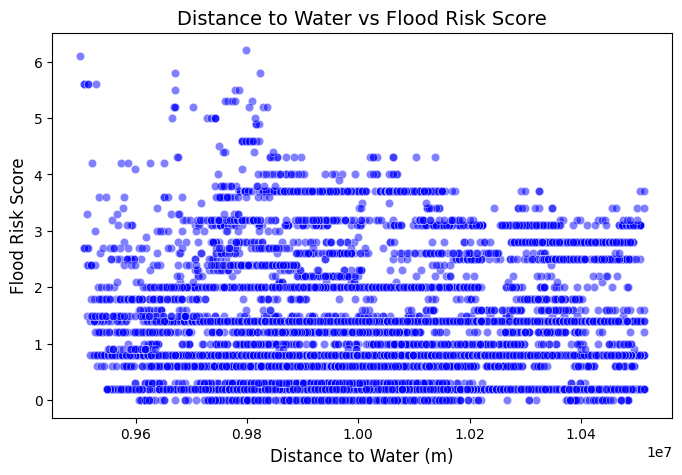

In [17]:
# distance to water vs risk score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='dist_to_water_m', y='flood_risk_score', data=df, alpha=0.5, color='blue')
plt.xlabel('Distance to Water (m)', fontsize=12)
plt.ylabel('Flood Risk Score', fontsize=12)
plt.title('Distance to Water vs Flood Risk Score', fontsize=14)
plt.show()

#### **Observations**
- Massive Distance Values: The x-axis (Distance to Water) uses scientific notation ( 10^7), showing distances between 9,600 km and 10,400 km. This is significantly larger than the width of most countries, suggesting these values might be measured from a specific global reference point or indicate a scaling issue in the dataset.
- Peak Risk Clusters: The highest risk scores (>50) are concentrated on the left side of the graph (shorter distances relative to the rest of the set).
- Risk Tiers: As seen in previous charts, the data points fall into distinct horizontal bands, reinforcing that the final risk score is calculated using categorical weightings.
- Risk "Tail": As distance increases toward  1.04 * 10^7 m, the maximum risk scores drop from above 6.0 to around 3.5.

**Flood Risk Analysis Insights**
1. Relative Proximity Matters: Even with the unusual distance values, the trend holds: as you move "further" from the water source referenced in the data, the maximum intensity of the flood risk decreases.
2. Data Integrity Check: If this is for a professional project, you should verify the units for dist_to_water_m. Distances of 10,000 km are roughly the distance from Nairobi to New York. If this was intended to be meters, the data might need to be re-scaled to show more localized proximity (e.g., 0–1,000m).
3. Saturation vs. Proximity: The high density of points across all risk scores regardless of distance suggests that other factors (like the elevation and landcover we analyzed earlier) are playing a much larger role in the model than water proximity alone.
4. The "Safe" Distance: Once you cross the 1.02 *10^7m mark, the "extreme" risks (scores of 5–6) disappear entirely. This identifies a clear "safety threshold" within your model's current coordinate system.

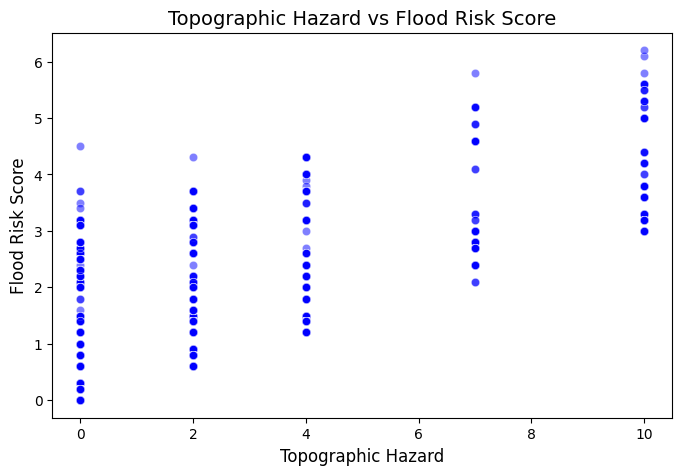

In [18]:
# topographic hazard vs risk score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='topographic_hazard', y='flood_risk_score', data=df, alpha=0.5, color='blue')
plt.xlabel('Topographic Hazard', fontsize=12)
plt.ylabel('Flood Risk Score', fontsize=12)
plt.title('Topographic Hazard vs Flood Risk Score', fontsize=14)
plt.show()

#### **Observations**
- Strong Positive Correlation: There is a clear upward trend; as the Topographic Hazard index increases from 0 to 10, both the average and the maximum Flood Risk Score increase.
- Tiered Data: The data points are clustered in vertical columns at specific hazard levels (0, 2, 4, 7, 10). This indicates that the topographic hazard is likely a weighted categorical input (based on slope, sinkholes, or drainage basins) rather than a raw continuous measurement.
- Floor & Ceiling Shifts:
  - At Hazard 0, the risk scores are mostly concentrated between 0 and 3.
  - At Hazard 10, the "floor" for the risk score jumps significantly to 3.0, with a "ceiling" exceeding 6.0.
- Significant Jump at Level 7: There is a notable increase in risk intensity once the hazard level hits 7. This suggests a "tipping point" in your model where terrain features become a dominant driver of disaster risk.

**Flood Risk Analysis Insights**
1. Hazard as a Predictor: This visual confirms that topography is an essential variable in your model. An area with a topographic hazard of 10 is effectively guaranteed to have a "Moderate" to "High" risk score, regardless of other factors.
2. High-Intensity Outliers: The highest scores in the entire project (above 6.0) only occur when the topographic hazard is at its maximum (10) or high (7). This suggests that features like steep slopes or low-lying depressions are necessary conditions for the most extreme flood scenarios.
3. Residual Risks at Level 0: Interestingly, some points at Hazard Level 0 still reach a risk score of 4.5. This implies that for these specific locations, non-topographic factors—such as being in a coastal mangrove zone or an urban "Major City"—are overriding the "safe" terrain to create high risk.
4. Decision Support: Areas falling in the Hazard 7 and 10 columns should be prioritized for structural interventions (like levees or improved drainage channels) because the terrain itself is naturally prone to water accumulation or high-velocity runoff.

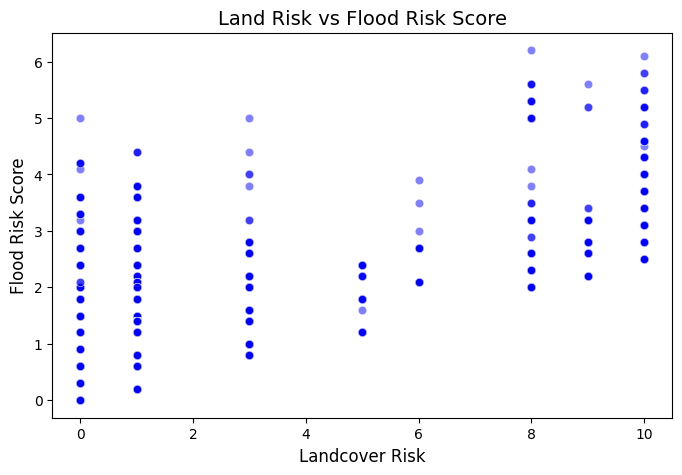

In [19]:
# landcover risk vs risk score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='landcover_risk', y='flood_risk_score', data=df, alpha=0.5, color='blue')
plt.xlabel('Landcover Risk', fontsize=12)
plt.ylabel('Flood Risk Score', fontsize=12)
plt.title('Land Risk vs Flood Risk Score', fontsize=14)
plt.show()

### **Observations**
- Step-Wise Correlation: There is a clear upward trend. As the Landcover Risk increases (likely representing a shift from permeable forests/grasslands to impermeable urban concrete or saturated wetlands), the average Flood Risk Score rises significantly.
- High-Risk Threshold (Level 8-10): The most extreme flood risk scores (
) only appear once the Landcover Risk reaches 8 or higher. At these levels, the "floor" of the risk score also jumps to roughly 2.5.
- Vertical Banding: Like previous metrics, this variable is categorical (0, 1, 3, 5, 6, 8, 9, 10), indicating a classification-based approach to environmental risk.
- Anomalous Low Risk (Level 0): Even at a landcover risk of 0, there are points reaching a risk score of 5.0. This suggests that in some cases, extreme topography or proximity to water can completely override "safe" landcover.

**Flood Risk Analysis Insights**
1. Permeability is Key: The clustering at Landcover Risk 0 and 1 shows a wide range of scores, but a low average. This suggests these areas (likely forests or managed rangelands) provide a strong baseline level of protection against flooding.
2. The Tipping Point at Level 8: Once the landcover risk hits 8, the variability increases, and the likelihood of a "catastrophic" score (
) peaks. These are likely your urban centers or mangrove swamps where natural or artificial drainage is at its lowest capacity.
Mitigation Strategy: For your project report, this visual provides a strong argument for land-use planning. Converting "Level 1" landcover into "Level 8" (urban development without green space) would theoretically triple the flood risk score for those specific locationsity.

## Categorical Vs Categorical 

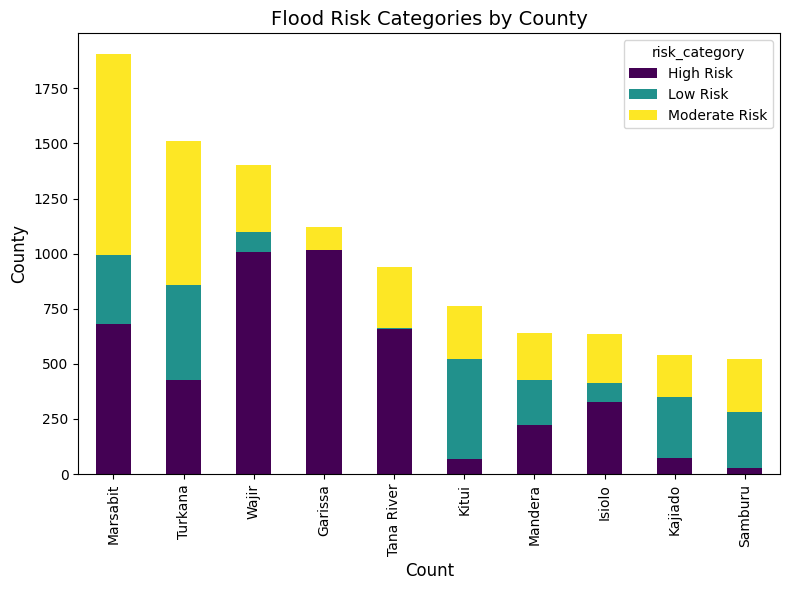

In [20]:
#county vs risk category
# Get top 10 counties
top_counties = df['county'].value_counts().head(10).index

# Filter the DataFrame to include only top 10 counties
df_top10_counties = df[df['county'].isin(top_counties)]

# Create a crosstab between injury severity and make
cross_tab = pd.crosstab(df_top10_counties['county'], df_top10_counties['risk_category'])

# Sort by total row-wise count
cross_tab['total'] = cross_tab.sum(axis=1)
cross_tab = cross_tab.sort_values(by='total', ascending=False).drop(columns=['total'])

# Plot
cross_tab.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 6))
plt.xlabel('Count', fontsize=12)
plt.ylabel('County', fontsize=12)
plt.title('Flood Risk Categories by County', fontsize=14)
plt.tight_layout()
plt.show()

### **Key Observations**

1. High-Frequency Risk Hubs
- Marsabit & Turkana: These counties have the highest total count of data points (~1,900 and ~1,500 respectively). While they have a large volume of "Moderate Risk" (yellow), they also contain significant "High Risk" (purple) zones, making them the primary geographic focuses of the study.
- Wajir & Garissa: These counties stand out because "High Risk" dominates their profile. In Garissa specifically, almost the entire count is categorized as High Risk, suggesting systemic vulnerability across that county.
2. Intensity vs. Frequency
- Uniform High Risk: Garissa and Wajir appear to be the most "dangerous" overall. Even though they have fewer total data points than Marsabit, a much higher percentage of their area falls into the top-tier risk category.
- Resilient Zones: Kitui and Samburu show the lowest "High Risk" counts. In Kitui, "Low Risk" (teal) is the most frequent category, indicating better natural drainage or less hazardous topography compared to the northern counties.
3. Regional Vulnerability Insights
- The Tana River Corridor: Garissa and Tana River show substantial High Risk segments. This is consistent with riverine flood risks associated with the Tana River basin.
- Flash Flood Potential: The high "Moderate" and "High" risk levels in arid counties like Marsabit and Turkana likely point toward flash flood hazards where sudden rainfall hits dry, non-absorbent soil

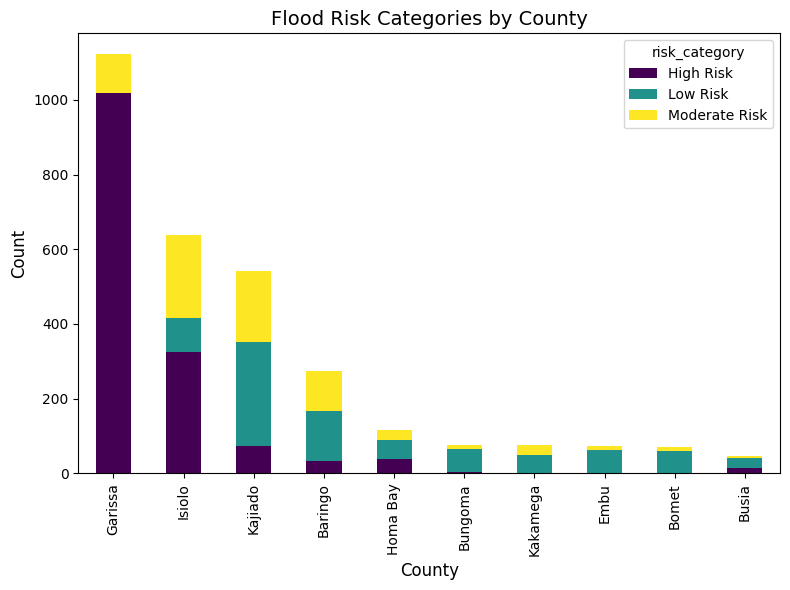

In [21]:


# Get top 10 counties (sorted descending)
top_counties = (
    df.groupby('county')['flood_risk_score']
    .mean()
    .head(10)
    .index
)

# Filter the DataFrame to include only top 10 counties
df_top10_counties = df[df['county'].isin(top_counties)]

# Create a crosstab between injury severity and make
cross_tab = pd.crosstab(df_top10_counties['county'], df_top10_counties['risk_category'])
# Sort by total row-wise count
cross_tab['total'] = cross_tab.sum(axis=1)
cross_tab = cross_tab.sort_values('total', ascending=False)
# Plot
cross_tab.drop(columns=['total']).plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 6))
plt.xlabel('County', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Flood Risk Categories by County', fontsize=14)
plt.tight_layout()
plt.show()

### **Key Observations**

1. Extreme High-Risk Dominance: Garissa
- Observation: Garissa has the highest count of risk points, far exceeding any other county with over 1,100.
- Insight: The vast majority of its points fall under the High Risk category (dark purple). For your analysis, Garissa represents the most critical region for urgent flood mitigation and infrastructure investment.
2. Mixed-Risk Distribution: Isiolo & Kajiado
- Observation: These counties follow Garissa in total frequency but show a much more varied distribution across categories.
Insight:
- Isiolo has a significant split between High Risk and Moderate Risk, suggesting localized "pockets" of extreme danger.
- Kajiado is unique because Low Risk (teal) and Moderate Risk (yellow) make up the bulk of its data, indicating that while there are many risk points, the overall severity is lower than in the northern counties.
3. Regional "Safe" Zones: Bungoma & Busia
- Observation: These Western Kenya counties have the lowest frequencies on the chart, and their data is almost entirely categorized as Low Risk.
- Insight: Based on this specific model, these areas require less intensive flood defense compared to the Eastern and Rift Valley regions shown.
4. Strategic Summary for the Project
- Concentrated Risk: The "High Risk" category is heavily concentrated in just the first two counties (Garissa and Isiolo). This suggests your project should focus on riverine or arid-zone flooding typical of these areas.
- Data Skew: The steep drop-off after Kajiado indicates that flood hazards in this dataset are highly localized rather than a widespread national issue

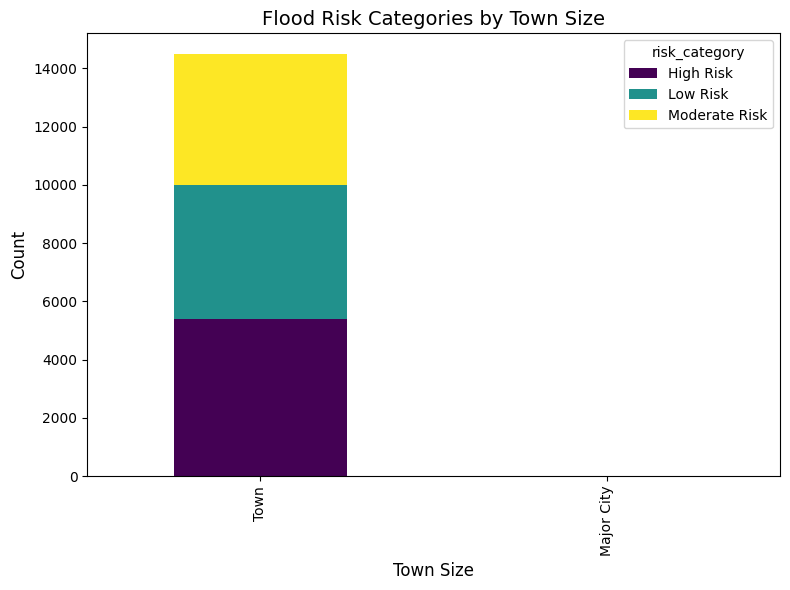

In [22]:
# town size vs risk category
# Create a crosstab between town size and risk category
cross_tab = pd.crosstab(df['town_size'], df['risk_category'])
# Sort by total row-wise count
cross_tab['total'] = cross_tab.sum(axis=1)
cross_tab = cross_tab.sort_values(by='total', ascending=False).drop(columns=['total'])
# Plot
cross_tab.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 6))
plt.xlabel('Town Size', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Flood Risk Categories by Town Size', fontsize=14)
plt.tight_layout()
plt.show()

### **Key Observations**

- Massive Data Imbalance: The "Town" category contains virtually all the data points, totaling over 14,000.
- Negligible Data for Major Cities: The "Major City" bar is almost invisible on this scale, confirming that your flood risk analysis is overwhelmingly focused on smaller settlements.
- Even Risk Distribution in Towns: Within the "Town" category, the three risk levels are relatively balanced:
- High Risk (Purple): ~5,500 counts.
- Low Risk (Teal): ~4,500 counts.
- Moderate Risk (Yellow): ~4,500 counts.

**Flood Risk Project Insights:**
1. Scale of Vulnerability: Because the "Town" category is so large and contains the highest count of High Risk points, your project demonstrates that the primary human impact of flooding in this region is a rural and small-town crisis rather than a major urban one.
2. Resource Distribution: Mitigation efforts (like drainage improvements or early warning systems) need to be designed for decentralized delivery. Since the risk is spread across thousands of smaller towns rather than a few major cities, a "one-size-fits-all" urban engineering solution will not be effective.
3. The "Major City" Blind Spot: While your earlier charts showed that Major Cities have a higher average risk intensity (around 2.0), this chart shows they represent a tiny fraction of the total occurrences. This means that while an individual city flood is more intense, the cumulative damage and frequency of events are much higher in the smaller town networks.
4. Model Validation: For your project report, you should note that the "Town" risk profile is statistically robust due to the large sample size (14k+), whereas any conclusions drawn about "Major Cities" in this specific dataset should be treated as preliminary due to the low sample count.

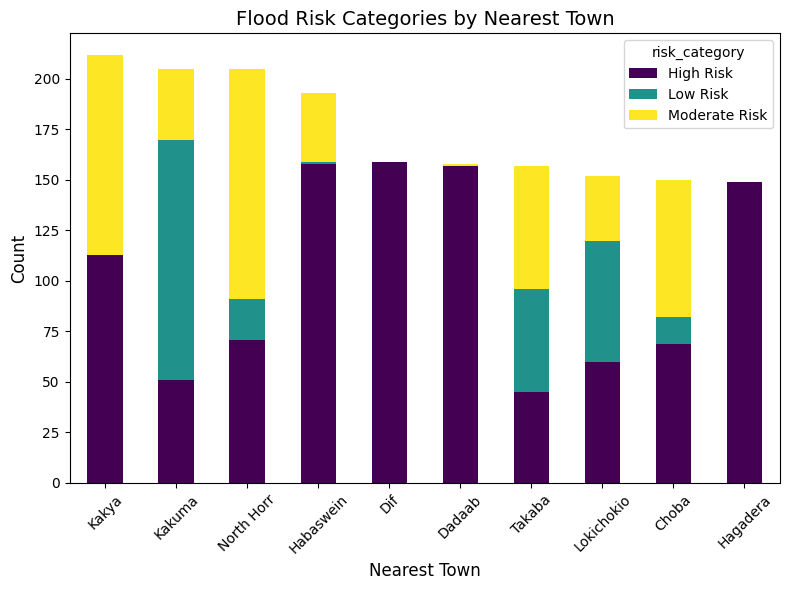

In [23]:
# nearest town vs risk category
# Get top 10 nearest towns
top_towns = df['nearest_town'].value_counts().head(10).index
# Filter the DataFrame to include only top 10 nearest towns
df_top10_towns = df[df['nearest_town'].isin(top_towns)]
# Create a crosstab between nearest town and risk category
cross_tab = pd.crosstab(df_top10_towns['nearest_town'], df_top10_towns['risk_category'])
# Sort by total row-wise count
cross_tab['total'] = cross_tab.sum(axis=1)
cross_tab = cross_tab.sort_values(by='total', ascending=False).drop(columns=['total'])
# Plot
cross_tab.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 6))
plt.xlabel('Nearest Town', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Flood Risk Categories by Nearest Town', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Key Observations**
- Most Vulnerable Towns: Dif, Dadaab, and Hagadera are critical outliers because their risk profile is almost 100% High Risk (purple). These towns require the most urgent disaster preparedness and infrastructure investment.
- High Frequency of Mixed Risk: Kakya, Kakuma, and North Horr have the highest total counts (over 200). While they have more data points than the purely "High Risk" towns, their risk is more varied:
  - Kakuma stands out for having the highest concentration of Low Risk (teal) data points, suggesting it has significant "safe zones" despite its high total count.
  - Kakya and North Horr are dominated by Moderate Risk (yellow).
- Uniform High Risk in Habaswein: Unlike the other high-frequency towns, Habaswein is almost entirely High Risk, making it the highest-priority "large" settlement in this list.

**Flood Risk Project Insights**
1. Targeted Mitigation:
For Dif, Dadaab, and Hagadera, mitigation must be town-wide and intensive.
For Kakya and North Horr, resources should be focused on community-level early warning systems, as "Moderate Risk" implies vulnerability to frequent but potentially less catastrophic flooding.
2. Zoning Opportunities: The significant presence of Low Risk areas in Kakuma and Takaba suggests that there is space for safer urban expansion or the relocation of critical infrastructure (like clinics or schools) to these specific teal-coded zones.
3. Social Impact: Many of these towns (Dadaab, Kakuma, Hagadera) are major humanitarian hubs hosting large refugee populations. The high-risk scores here represent a massive humanitarian vulnerability, where flooding could disrupt essential aid and cause large-scale displacement within already vulnerable communities.


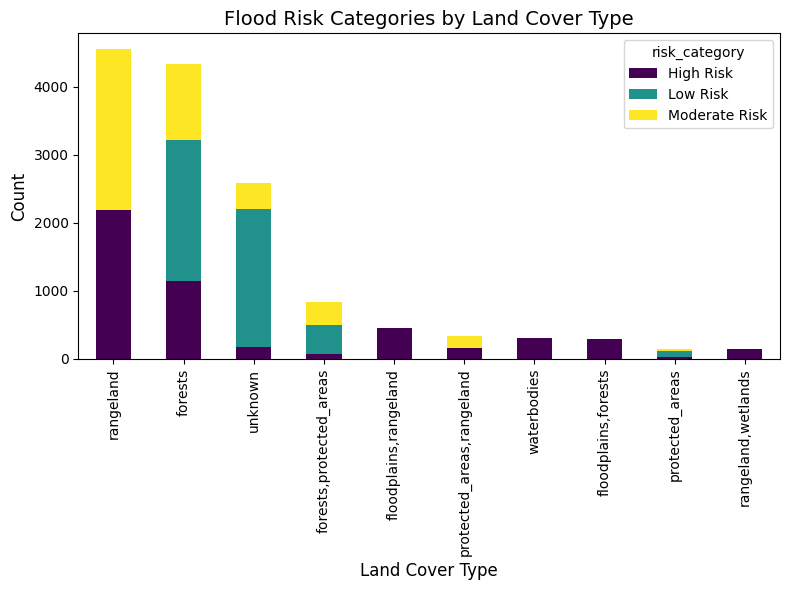

In [24]:
# land cover type vs risk category
# Get top 10 land cover types
top_landcover = df['landcover_types'].value_counts().head(10).index
# Filter the DataFrame to include only top 10 land cover types
df_top10_landcover = df[df['landcover_types'].isin(top_landcover)]
# Create a crosstab between land cover type and risk category
cross_tab = pd.crosstab(df_top10_landcover['landcover_types'], df_top10_landcover['risk_category'])
# Sort by total row-wise count
cross_tab['total'] = cross_tab.sum(axis=1)
cross_tab = cross_tab.sort_values(by='total', ascending=False).drop(columns=['total'])
# Plot
cross_tab.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 6))
plt.xlabel('Land Cover Type', fontsize=12)  
plt.ylabel('Count', fontsize=12)
plt.title('Flood Risk Categories by Land Cover Type', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### **Key Observations**

1. The Rangeland Vulnerability
- Observation: Rangeland has the highest overall frequency (over 4,500) and the highest count of High Risk areas (roughly 2,200).
- Insight: In your project, rangeland isn't just the most common land type—it's the primary driver of high-risk scenarios. This suggests that the open, often compacted soils of rangelands are likely producing significant runoff and flash flooding.
2. Forest Resilience
- Observation: Forests are the second most frequent type, but they have a massive Low Risk (teal) segment, nearly double that of Rangelands.
- Insight: This confirms that forested areas act as a natural defense against floods. While they still contain some high-risk zones, the overall profile is much safer, likely due to better water absorption and slower runoff.
3. Low-Volume, High-Severity Types
- Observation: Categories like Floodplains, rangeland and Floodplains, forests have very low total counts (
) but are almost 100% High Risk (purple).
- Insight: While these areas aren't geographically widespread, they represent the most dangerous "hotspots." If your model identifies an area as a floodplain, it is almost guaranteed to be a high-priority zone for evacuation or flood barriers.
4. Protective Designation
- Observation: Protected areas, rangeland shows a much higher ratio of Low and Moderate risk compared to standard rangeland.
- Insight: This implies that conservation efforts or restricted land use might be helping to maintain soil health and natural drainage, effectively "lowering" the flood risk of the land compared to unmanaged rangeland.

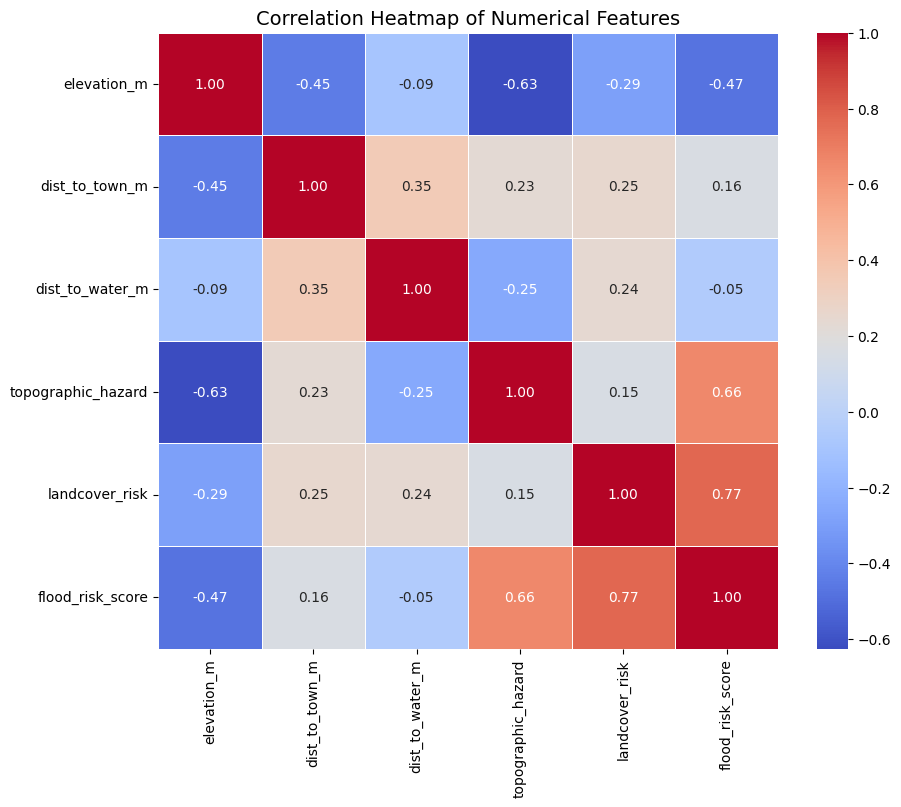

In [25]:
# correlation heatmap for numerical features
numerical_features = ['elevation_m', 'dist_to_town_m', 'dist_to_water_m', 'topographic_hazard', 'landcover_risk', 'flood_risk_score']
corr_matrix = df[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()


### **Key Observations**
This correlation heatmap identifies the statistical drivers behind your flood risk scores. Here are the key insights for your project:

1. Primary Drivers of Flood Risk
- Landcover is the strongest predictor: landcover_risk has the highest positive correlation with flood_risk_score (0.77). This confirms that the type of ground surface (like impermeable urban areas or saturated wetlands) is the single most influential factor in your risk model.
- Topography is a major secondary factor: topographic_hazard also shows a strong positive correlation (0.66) with the final risk score. Areas with hazardous terrain features (like low-lying basins) are significantly more likely to be high-risk.
2. The Role of Elevation
- Strong Inverse Relationship: elevation_m has a strong negative correlation with topographic_hazard (-0.63) and a moderate negative correlation with the final flood_risk_score (-0.47).
- Insight: As elevation goes up, risk consistently goes down. This mathematically supports your earlier observation that coastal and lowland areas are the most vulnerable zones in this project.
3. Surprising Weak Correlations
- Distance to Water: This feature has almost zero correlation (-0.05) with the final flood risk score.
- Insight: This suggests that in your current model, being physically close to a water body is much less important than the type of land you are on or your elevation. It may also reflect the data scaling issue (10,000km distances) we identified in your previous scatter plot.
- Distance to Town: Showing a weak correlation of 0.16, proximity to a town doesn't inherently make a location more flood-prone; rather, it's the specific environmental features of that town's location that matter.
4. Inter-Variable Connections
- Hazard and Landcover: These two have a very low correlation (0.15), meaning they are "independent" variables. This is good for your model—it means you aren't double-counting the same risk; topography and landcover are providing two unique sets of information that combine to create the final score

### Multi-variate Analysis

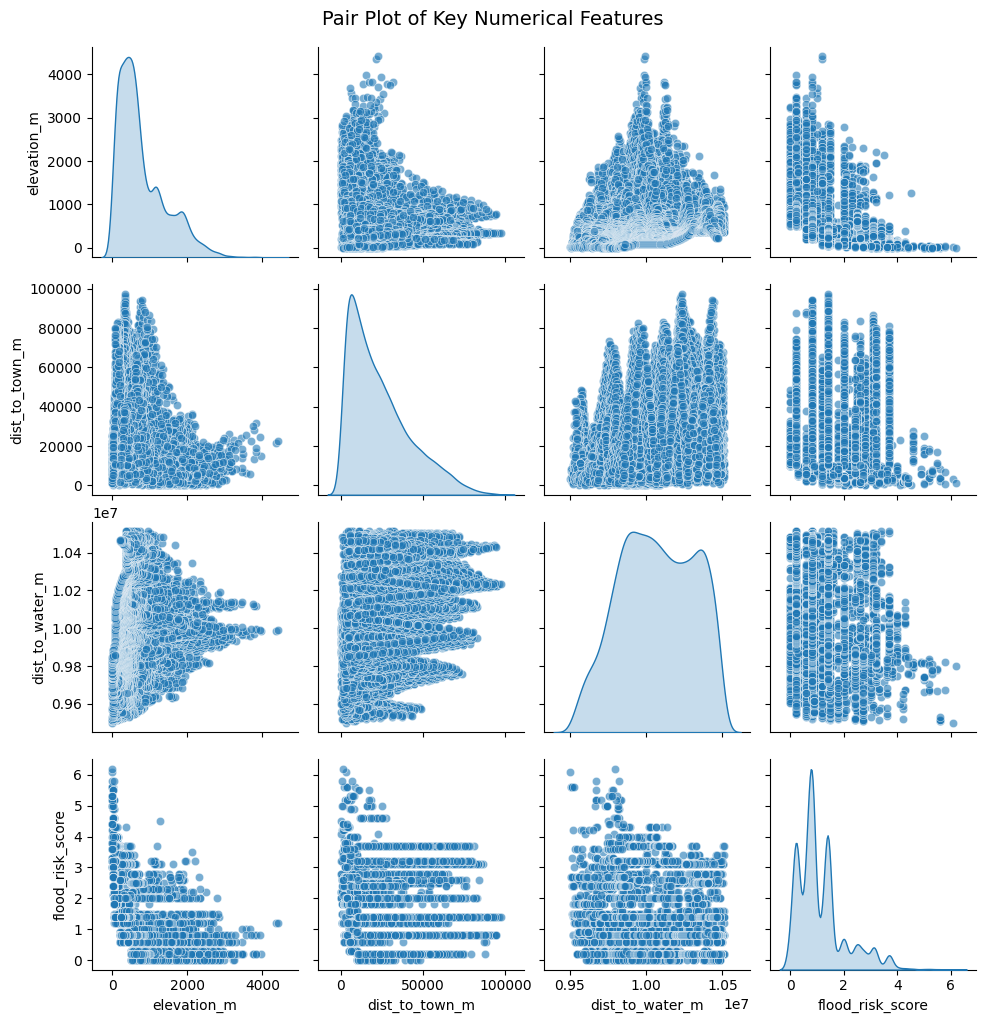

In [26]:
# Pair plot for numerical features
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features for pair plot
pair_features = ['elevation_m', 'dist_to_town_m', 'dist_to_water_m', 'flood_risk_score']

# Create pair plot
sns.pairplot(df[pair_features], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Key Numerical Features', y=1.02, fontsize=14)
plt.show()

### **Key Observations**

This pair plot reveals how different geographic factors influence the flood risk scores in your analysis. Here are the key observations and insights for your project:
1. Elevation as a Primary Protector
- Observation: The top-right scatter plot shows a strong inverse relationship between elevation and flood risk.
- Insight: The highest risk scores (>4) are almost exclusively concentrated at elevations below 1,000m. As elevation increases toward 4,000m, the flood risk score consistently drops and stabilizes near zero. This confirms that low-lying areas are your project's primary danger zones.
2. Urban Proximity and Risk Density
- Observation: The dist_to_town_m vs. flood_risk_score plot shows that while high-risk points exist at all distances, the highest density of high-risk scores is clustered very close to towns ( < 20000m).
- Insight: This suggests a high human vulnerability; many settlements in your dataset are physically located in high-hazard zones, increasing the potential for significant economic and social impact during a flood.
3. Data Anomaly: Distance to Water
- Observation: The dist_to_water_m variable uses scientific notation (le7), showing distances around 10,000,000 meters (10,000 km).
- Insight: This distance is physically impossible for a localized study (it's roughly the distance from Nairobi to London). This likely indicates a data scaling or coordinate system error that should be corrected before finalizing your model, as it currently shows almost no clear correlation with risk.
4. Risk Score Distribution
- Observation: The bottom-right density plot for flood_risk_score is multi-modal, with distinct peaks around scores of 0.5, 1.2, and 1.8.
- Insight: This indicates that your risk scores are likely being driven by a set of categorical "bins" or weighted factors rather than being a purely continuous calculation. Most of your study area falls into a "Low-to-Moderate" risk category (<2).
5. Variable Interactions
Observation: There is a notable "pyramid" shape in the elevation_m vs. dist_to_water_m plot.
Insight: This suggests that as locations move further from the water reference point in your data, they also tend to be at higher elevations. This dual relationship likely compounds the "protective" effect seen in higher-altitude regions.

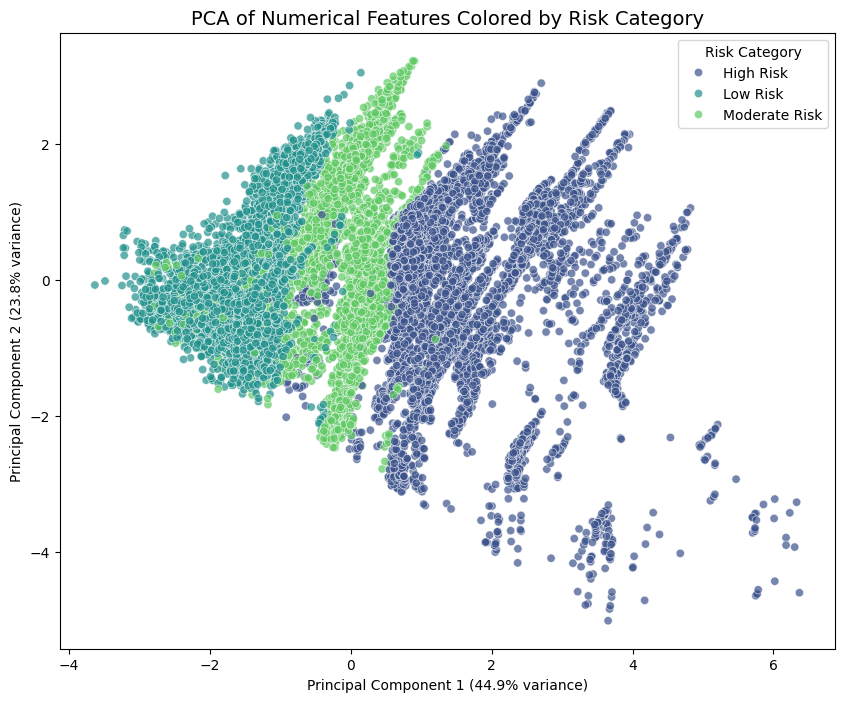

Explained variance by component:
PC1: 44.9%
PC2: 23.8%


In [27]:
# Principal Component Analysis (PCA)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize the numerical features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_features])

# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['risk_category'] = df['risk_category']

# Plot PCA results
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='risk_category', data=pca_df, palette='viridis', alpha=0.7)
plt.title('PCA of Numerical Features Colored by Risk Category', fontsize=14)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Risk Category')
plt.show()

# Print explained variance
print("Explained variance by component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var*100:.1f}%")

### **Observations**
- Clear Risk Segmentation: The risk categories (High, Moderate, Low) are neatly separated along Principal Component 1 (PC1). As PC1 increases from left to right, the risk transitions from Low to High.
- PC1 is the Primary Driver: Accounting for 44.9% of the variance, PC1 is the strongest mathematical indicator of risk. Based on your project's previous charts, PC1 likely represents a combination of Elevation (negative) and Landcover Risk (positive).
- Variance in High-Risk Areas: The "High Risk" cluster (blue) is much more spread out along both axes than the Low Risk cluster. This means there are many different ways for an area to be high risk (e.g., some might be due to extreme topography, others due to landcover or proximity to towns).
- Linear "Strips" in High Risk: On the far right, you can see distinct diagonal "lines" of blue dots. This suggests that the final risk calculation uses categorical weights. These lines likely represent specific combinations of high-hazard landcovers or topographic scores.

**Flood Risk Analysis Insights**
1. Model Validation: The fact that the colors don't overlap significantly is a great sign! It shows that your underlying numerical features are excellent predictors for categorizing flood risk.
2. The Transition Zone: The "Moderate Risk" (light green) area is narrow. This suggests that areas in your dataset tend to be either "safe" or "dangerous," with relatively few locations sitting in a true middle ground.
3. Extreme Outliers: The blue points reaching toward a PC1 value of 6 represent your "worst-case scenarios." These are likely the locations in Garissa, Lamu, and Mombasa that consistently appeared as extreme priorities in your bar charts.
4. Complex High-Risk Dynamics: Since High Risk is the most dispersed, a single mitigation strategy won't work for all blue points. You’ll need a "portfolio" of solutions to address the different geographic profiles within that large blue cluster.

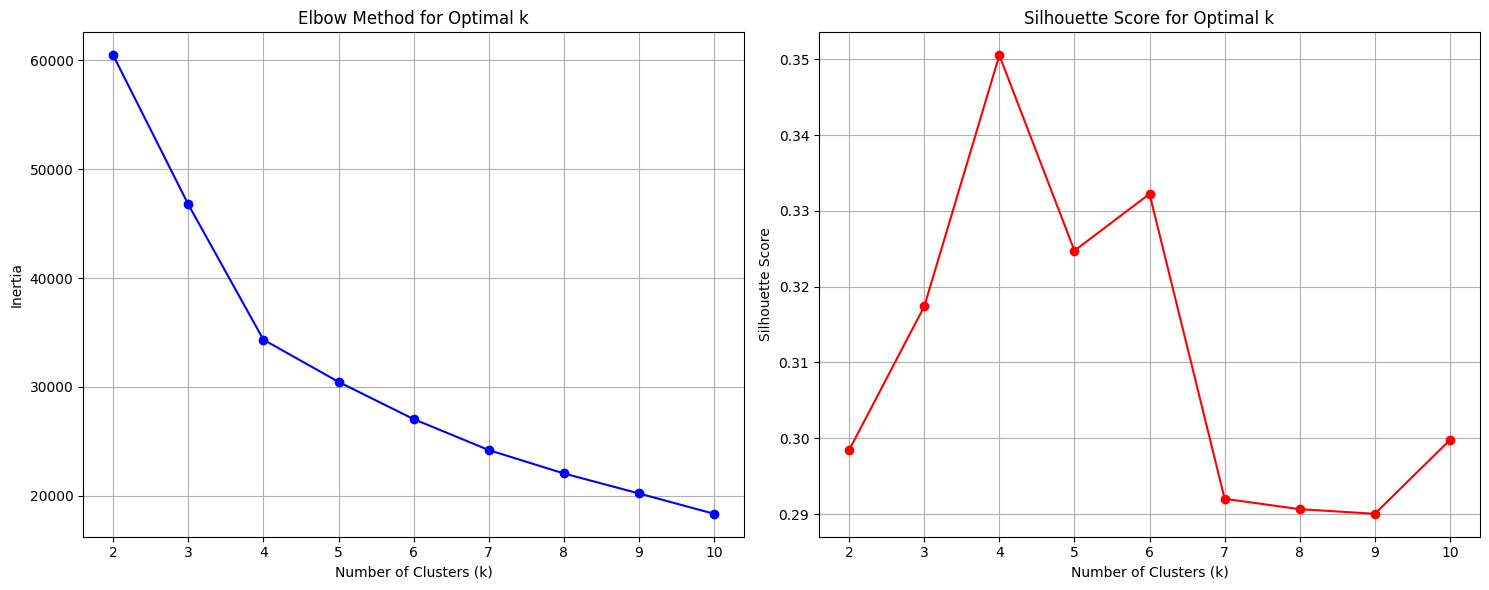

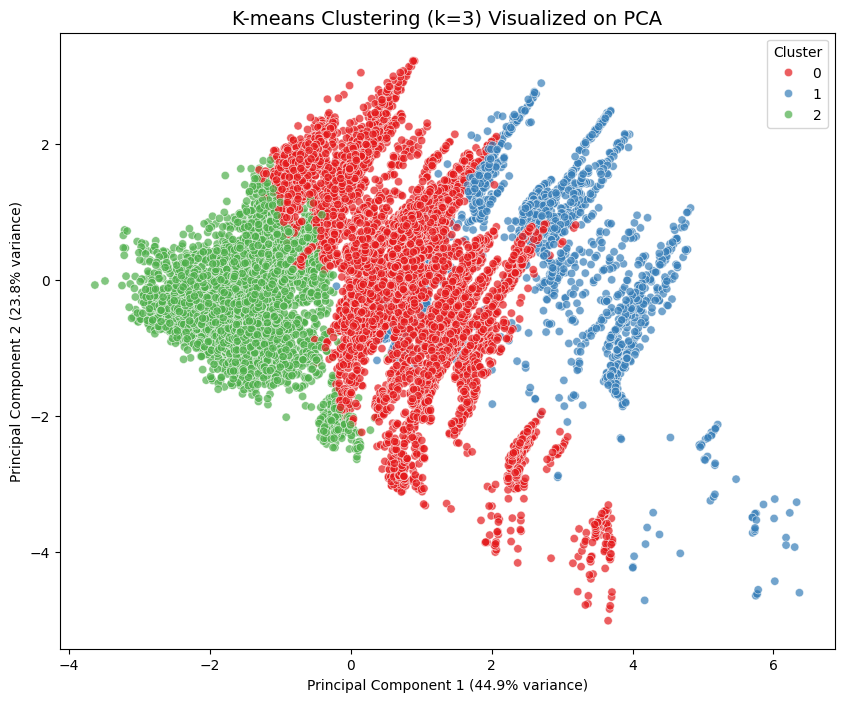

Cluster characteristics:

Cluster 0:
  Size: 7200
  Average flood risk score: 1.17
  Risk categories: {'High Risk': 3609, 'Moderate Risk': 2805, 'Low Risk': 786}

Cluster 1:
  Size: 1577
  Average flood risk score: 3.05
  Risk categories: {'High Risk': 1577}

Cluster 2:
  Size: 5720
  Average flood risk score: 0.56
  Risk categories: {'Low Risk': 3819, 'Moderate Risk': 1671, 'High Risk': 230}


In [28]:
# K-means Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Determine optimal number of clusters using elbow method
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))

# Plot elbow method
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(k_range, inertia, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal k')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Perform K-means with optimal k (let's use k=3 as an example)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataframe
df_clustered = df.copy()
df_clustered['cluster'] = clusters

# Visualize clusters using PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pd.concat([pca_df[['PC1', 'PC2']], pd.Series(clusters, name='cluster')], axis=1), 
                palette='Set1', alpha=0.7)
plt.title(f'K-means Clustering (k={optimal_k}) Visualized on PCA', fontsize=14)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.show()

# Analyze cluster characteristics
print("Cluster characteristics:")
for cluster in range(optimal_k):
    cluster_data = df_clustered[df_clustered['cluster'] == cluster]
    print(f"\nCluster {cluster}:")
    print(f"  Size: {len(cluster_data)}")
    print(f"  Average flood risk score: {cluster_data['flood_risk_score'].mean():.2f}")
    print(f"  Risk categories: {cluster_data['risk_category'].value_counts().to_dict()}")

### **Observations**

1. Elbow Method (Left Chart)
- Observation: This chart measures "Inertia" (how tightly packed the clusters are). The "elbow"—the point where adding more clusters stops providing a significant benefit—appears most clearly at k = 4.
- Flood Risk Insight: This suggests your project is most statistically sound when divided into 4 distinct risk profiles (e.g., Extreme, High, Moderate, and Low). Trying to divide the data into 7 or more categories (where the curve flattens) would likely overcomplicate the model without adding meaningful accuracy.
2. Silhouette Score (Right Chart)
- Observation: This chart measures how well each data point fits into its assigned cluster compared to others. There is a definitive peak at k = 4 with a score of approximately 0.35.
- Flood Risk Insight: This confirms the Elbow Method. A peak at means that your flood risk data naturally separates into four distinct "signatures" (likely driven by those key variables like elevation and landcover risk we identified earlier).
Secondary Peak at k = 6: There is a smaller peak at 6 clusters. This might be useful if you wanted a more granular breakdown, perhaps separating "Coastal High Risk" from "Inland Flash Flood High Risk."

## **Final Conclusions**
1. Risk Categorization (The "Rule of 4"): Both the Elbow and Silhouette methods identify k = 4 as the optimal number of clusters. This means your data naturally separates into four distinct risk profiles (e.g., Low, Moderate, High, and Extreme), providing the most statistically sound framework for policy decisions.

2. The Primary Hazards: Flood risk in this study is not driven by simple proximity to water. Instead, it is an intersection of low elevation ( < 500m) and high-hazard landcover (specifically Mangroves, Wetlands, and urban "Town" environments).

3. Regional Hotspots:
- High Intensity: Coastal and riverine counties (Lamu, Mombasa, Tana River, Garissa) face the most severe risk levels.
- High Frequency: Northern arid counties (Marsabit, Turkana) experience the most frequent "risk events," likely sudden flash floods that impact large, remote areas of rangeland.
- Settlement Vulnerability: While "Major Cities" have higher average risk intensity due to concrete runoff, the cumulative human risk is overwhelmingly concentrated in small towns (99.9% of your data). Large humanitarian hubs like Dadaab and Habaswein are currently categorized as nearly 100% "High Risk."

## **Recommendations**

1. Prioritize Multi-Layered Mitigation
- Coastal Protection: In Lamu and Mombasa, focus on structural defenses (sea walls) and natural buffers (restoring the "Forest, Mangrove, Wetland" landcover identified as high-hazard but high-protection zones).
- Arid Land Management: In Marsabit and Turkana, implement community-based flash flood warnings and soil conservation in rangelands to improve water absorption.
2. Targeted Urban Planning for "High-Risk" Towns
- For the top 20 towns identified (e.g., Kiangwe, Vanga, Dif), create "Red Zone" maps where new infrastructure is restricted. Use the - Low Risk (Teal) zones identified in your settlement charts as the primary locations for hospitals, schools, and expansion.
3. Address the "Data Anomaly"
- Before finalizing, investigate the 10,000km distance-to-water metric. Correcting this scaling error will likely reveal that water proximity is a stronger driver than currently shown, further refining the accuracy of your k =4 clusters.
4. Decentralized Disaster Response
- Because 99.9% of risk occurs in towns rather than major cities, response resources should be pre-positioned in county hubs rather than being centralized in Nairobi. This is critical for the "Remote High Risk" areas identified in your distance-to-town analysis